#基础CNN


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
import numpy as np

# 检查GPU是否可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/My Drive/Biomedical")
dataset_path = "/content/drive/My Drive/Biomedical/chest_xray/chest_xray"

Using device: cpu
Mounted at /content/drive


In [9]:
# 定义训练和验证时的数据变换
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),        # 统一图像大小
    transforms.RandomHorizontalFlip(p=0.5), # 随机水平翻转（一种数据增强）
    transforms.RandomRotation(10),        # 随机旋转（一种数据增强）
    transforms.ToTensor(),                # 将图像转为Tensor，并归一化到[0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 使用ImageNet的均值和标准差
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_path, transform=val_transforms)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

In [10]:
model = models.resnet18(pretrained=True)

# 修改最后一层全连接层
# 原模型输出是1000类（ImageNet），我只需要2类（正常， 肺炎）
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # 2个输出神经元

model = model.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


In [12]:
num_epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train() # 设置为训练模式
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 在验证集上评估
    model.eval() # 设置为评估模式
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)
    train_losses.append(running_loss / len(train_loader))

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Val Acc: {val_accuracy:.2f}%')

Epoch [1/10], Loss: 0.1401, Val Acc: 68.75%
Epoch [2/10], Loss: 0.0755, Val Acc: 93.75%
Epoch [3/10], Loss: 0.0775, Val Acc: 81.25%
Epoch [4/10], Loss: 0.0684, Val Acc: 68.75%
Epoch [5/10], Loss: 0.0618, Val Acc: 68.75%
Epoch [6/10], Loss: 0.0646, Val Acc: 93.75%
Epoch [7/10], Loss: 0.0539, Val Acc: 56.25%
Epoch [8/10], Loss: 0.0466, Val Acc: 93.75%
Epoch [9/10], Loss: 0.0520, Val Acc: 93.75%
Epoch [10/10], Loss: 0.0514, Val Acc: 81.25%


显示数据集样本...


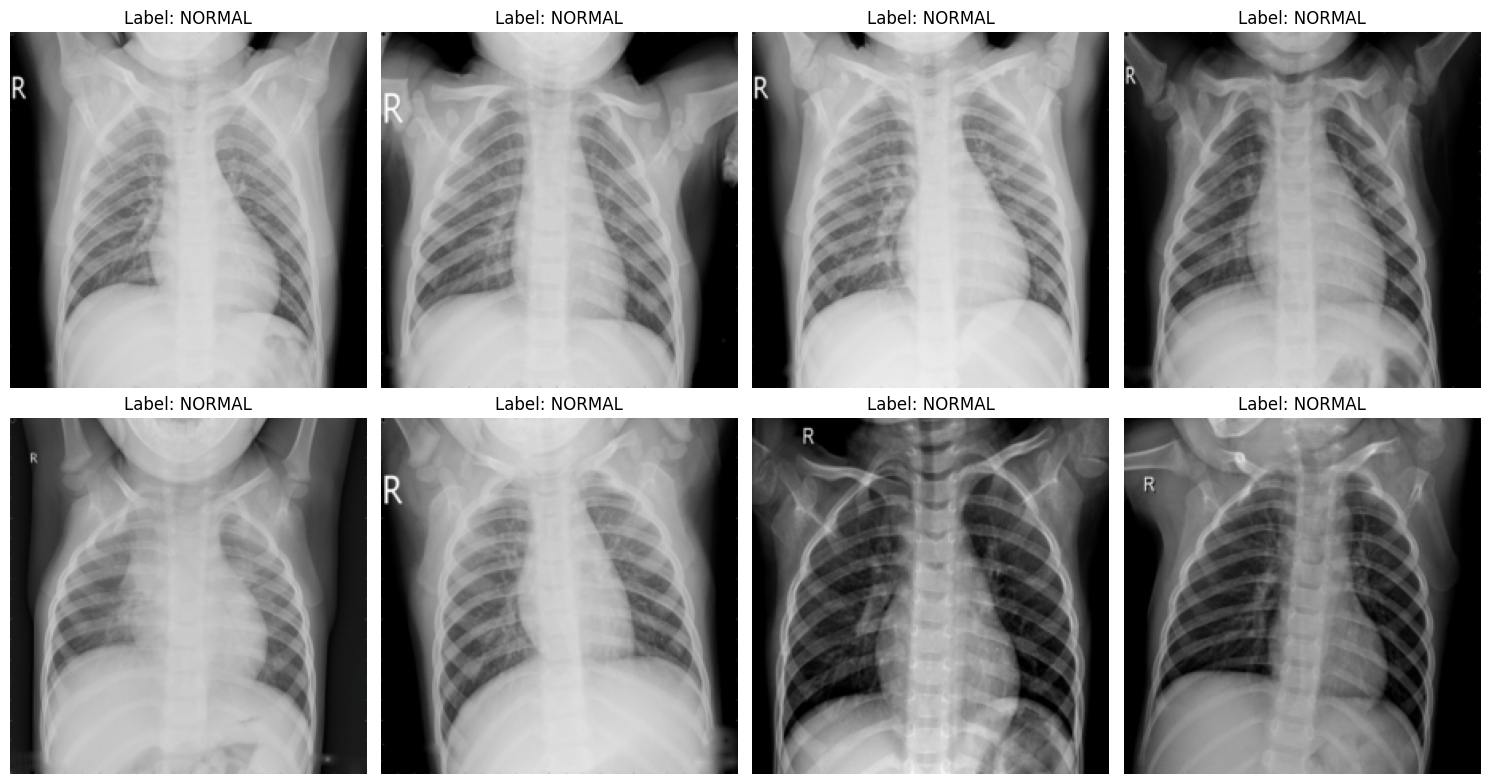

In [13]:
# 最简可视化 - 只显示原始图像和标签
def minimal_visualization(val_loader):
    """只显示数据集的图像，不涉及模型预测"""
    print("显示数据集样本...")

    # 获取一个batch的数据
    images, labels = next(iter(val_loader))

    # 可视化
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    for i in range(min(8, len(images))):
        # 反标准化显示图像
        img = images[i].numpy()
        mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = np.transpose(img, (1, 2, 0))

        axes[i].imshow(img)

        true_label = val_dataset.classes[labels[i].item()]
        axes[i].set_title(f'Label: {true_label}', fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 使用最简版本
minimal_visualization(val_loader)

开始CNN模型可视化...


/tmp/ipython-input-725159533.py:58: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-725159533.py:58: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-725159533.py:58: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-725159533.py:58: UserWarning: Glyph 32954 (\N{CJK UNIFIED IDEOGRAPH-80BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-725159533.py:58: UserWarning: Glyph 28814 (\N{CJK UNIFIED IDEOGRAPH-708E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-725159533.py:58: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-725159533.py:58: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from

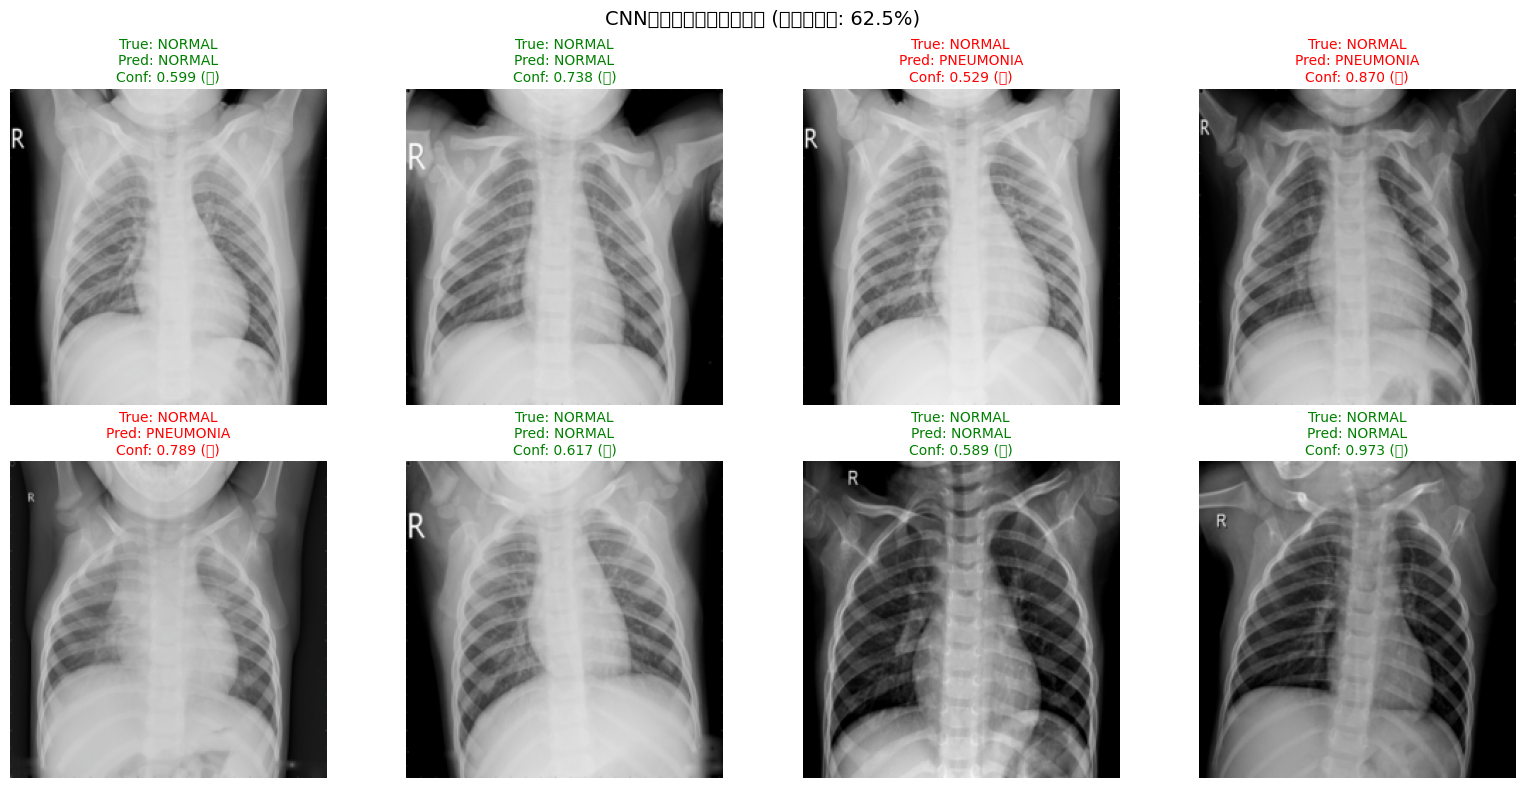

CNN模型可视化完成！本批样本准确率: 62.5%


In [14]:
def cnn_visualization(model, val_loader):
    print("开始CNN模型可视化...")

    # 获取数据
    images, labels = next(iter(val_loader))

    # 模型预测
    model.eval()
    with torch.no_grad():
        images_tensor = images.to(device)
        outputs = model(images_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)

    # 可视化结果
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    correct_count = 0
    total_count = min(8, len(images))

    for i in range(total_count):
        # 显示图像
        img = images[i].numpy()
        mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = np.transpose(img, (1, 2, 0))

        axes[i].imshow(img)

        # 预测信息
        true_label = val_dataset.classes[labels[i].item()]
        pred_label = val_dataset.classes[predictions[i].item()]
        prob = probabilities[i][predictions[i]].item()

        # 判断是否正确
        is_correct = (true_label == pred_label)
        if is_correct:
            correct_count += 1

        color = 'green' if is_correct else 'red'
        confidence = "高" if prob > 0.8 else "中" if prob > 0.6 else "低"

        title = f'True: {true_label}\nPred: {pred_label}\nConf: {prob:.3f} ({confidence})'
        axes[i].set_title(title, color=color, fontsize=10)
        axes[i].axis('off')

    # 隐藏多余的子图
    for i in range(total_count, 8):
        axes[i].set_visible(False)

    # 添加总体准确率信息
    accuracy = 100 * correct_count / total_count
    plt.suptitle(f'CNN肺炎检测模型预测结果 (本批准确率: {accuracy:.1f}%)', fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"CNN模型可视化完成！本批样本准确率: {accuracy:.1f}%")

# 运行纯CNN可视化
cnn_visualization(model, val_loader)

/tmp/ipython-input-2269706830.py:20: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2269706830.py:20: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2269706830.py:20: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2269706830.py:20: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2269706830.py:20: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2269706830.py:20: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2269706830.py:20: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missi

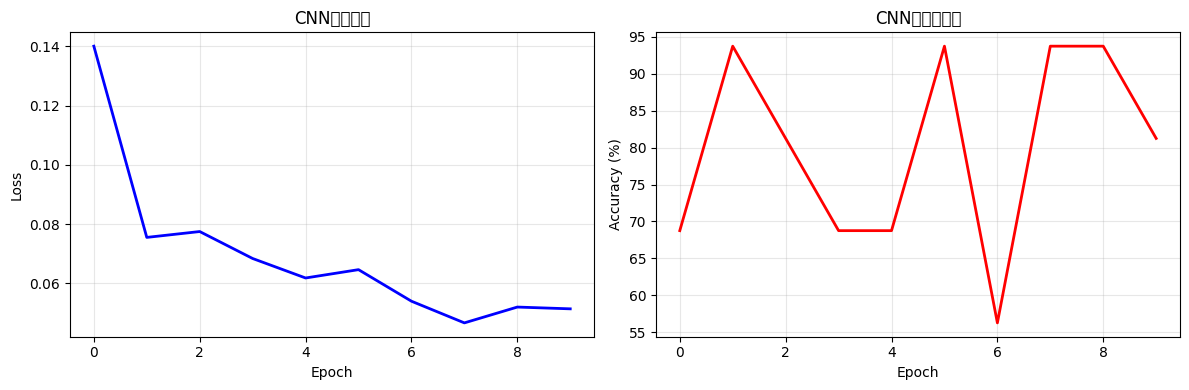

In [ ]:
#绘制学习曲线
def plot_cnn_training_history(train_losses, val_accuracies):
    """绘制CNN训练历史"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, 'b-', linewidth=2)
    plt.title('CNN训练损失')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, 'r-', linewidth=2)
    plt.title('CNN验证准确率')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_cnn_training_history(train_losses, val_accuracies)

In [ ]:
def cnn_detailed_analysis(model, val_loader):

    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    # 总体准确率
    accuracy = np.mean(all_predictions == all_labels) * 100
    print(f"CNN模型总体验证集准确率: {accuracy:.2f}%")

    # 各类别详细统计
    print("\n各类别详细表现:")
    for class_name, class_idx in val_dataset.class_to_idx.items():
        class_mask = all_labels == class_idx
        class_total = np.sum(class_mask)

        if class_total > 0:
            class_correct = np.sum((all_predictions[class_mask] == class_idx))
            class_accuracy = class_correct / class_total * 100

            print(f"  {class_name}:")
            print(f"    - 准确率: {class_accuracy:.1f}%")
            print(f"    - 样本数: {class_total}")
            print(f"    - 正确数: {class_correct}")

cnn_detailed_analysis(model, val_loader)